Revenue Prediction
==================
In this project the goal is to predict movies revenue using their features. revenue is given by ( box_office - budget ) so the main goal is to predict box office. 

1. Prepare and preprocess the given data. 

2. After exploring data find, select and especially create new features. ignore others.

3. Prepare features to feed the model. 

4. Select and try different models.

5. Document and report each step using relative plots and a brief explanation. finally report the best suited model and justify why did it performed well.



- Keep in mind that in this task accuracy itself only has only part of score.

- Hint: to create new features you can use credit attributes. Think of it this way, what affects box office?  

**Tools** 

importing useful tools and libraries. you may use any other library as well.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Modelling
from sklearn import preprocessing, svm 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

from datetime import datetime
import ast
import json
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# Text Processing Section
from ftfy import fix_text
import chardet


C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
np.random.seed(42)

In [3]:
# Your project struct must look like this,


# |── Name_SID.zip
# │   ├── data
# │   │       ├── rotten_tomatoes_5000_movies.csv
# │   │       ├── rotten_tomatoes_5000_movies.csv
# │   ├── *.ipynb
# │   ├── document.pdf

df_movies = pd.read_csv(r"data/rotten_tomatoes_5000_movies.csv")
df_credit = pd.read_csv(r"data/rotten_tomatoes_5000_credits.csv")


<h1>DataSet Informations</h1>

<h3> Movies Dataset Information </h3>

In [4]:
display(df_movies.head())
df_movies.info()

,rt_production_budget,rt_genres,rt_website,rt_movie_id,rt_keywords,rt_original_language,rt_original_title,rt_synopsis,rt_audience_score,rt_studios,rt_production_countries,rt_release_date,rt_box_office,rt_runtime,rt_languages,rt_release_status,rt_tagline,rt_title,rt_critics_score,rt_review_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rt_production_budget     4803 non-null   int64  
 1   rt_genres                4803 non-null   object 
 2   rt_website               1712 non-null   object 
 3   rt_movie_id              4803 non-null   int64  
 4   rt_keywords              4803 non-null   object 
 5   rt_original_language     4803 non-null   object 
 6   rt_original_title        4803 non-null   object 
 7   rt_synopsis              4800 non-null   object 
 8   rt_audience_score        4803 non-null   float64
 9   rt_studios               4803 non-null   object 
 10  rt_production_countries  4803 non-null   object 
 11  rt_release_date          4802 non-null   object 
 12  rt_box_office            4803 non-null   int64  
 13  rt_runtime               4801 non-null   float64
 14  rt_languages            

In [5]:
df_movies['rt_box_office'].eq(0).sum()


1427

<h3> Credit Dataset Information </h3>

In [6]:
display(df_credit.head())
df_credit.info()
df_credit.describe()
print("Total null values: ", df_credit.isnull().sum().sum())

,rt_movie_id,rt_title,rt_actors,rt_staff
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   rt_movie_id  4803 non-null   int64 
 1   rt_title     4803 non-null   object
 2   rt_actors    4803 non-null   object
 3   rt_staff     4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB
Total null values:  0


In [7]:
df_movies_rt = df_movies[df_movies['rt_box_office']!=0]
y = df_movies_rt['rt_box_office']
X = df_movies_rt.drop(columns='rt_box_office')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25) 

In [8]:
df_movies_rt.info()
df_movies_rt.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 3376 entries, 0 to 4798
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rt_production_budget     3376 non-null   int64  
 1   rt_genres                3376 non-null   object 
 2   rt_website               1396 non-null   object 
 3   rt_movie_id              3376 non-null   int64  
 4   rt_keywords              3376 non-null   object 
 5   rt_original_language     3376 non-null   object 
 6   rt_original_title        3376 non-null   object 
 7   rt_synopsis              3376 non-null   object 
 8   rt_audience_score        3376 non-null   float64
 9   rt_studios               3376 non-null   object 
 10  rt_production_countries  3376 non-null   object 
 11  rt_release_date          3376 non-null   object 
 12  rt_box_office            3376 non-null   int64  
 13  rt_runtime               3376 non-null   float64
 14  rt_languages             3376

,rt_production_budget,rt_movie_id,rt_audience_score,rt_box_office,rt_runtime,rt_critics_score,rt_review_count
count,3.376000e+03,3376.000000,3376.000000,3.376000e+03,3376.000000,3376.000000,3376.000000
mean,3.888424e+07,45518.799171,28.260492,1.170314e+08,110.382109,6.308738,944.422690
std,4.420490e+07,74725.406344,35.622362,1.834831e+08,21.116082,0.882279,1392.846418
min,0.000000e+00,5.000000,0.019984,5.000000e+00,0.000000,0.000000,0.000000
25%,8.500000e+06,5538.250000,9.957286,1.535290e+07,96.000000,5.800000,160.750000
50%,2.500000e+07,11581.500000,19.755221,5.175184e+07,106.000000,6.300000,440.500000
75%,5.200000e+07,47370.750000,36.425937,1.401651e+08,121.000000,6.900000,1091.250000
max,3.800000e+08,417859.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [9]:
print("Before Removing 0s of rt_box_office:\n")
print(df_movies.isnull().sum()[df_movies.isnull().sum() > 0])

print("\nNull Percentage:")
null_percent = (df_movies.isnull().sum() / len(df_movies)) * 100
null_percent = null_percent[null_percent > 0]  # فقط ستون‌هایی که مقدار Null دارند

print(null_percent)

print("\nTotal null values: ", df_movies.isnull().sum().sum())

Before Removing 0s of rt_box_office:

rt_website         3091
rt_synopsis           3
rt_release_date       1
rt_runtime            2
rt_tagline          844
dtype: int64

Null Percentage:
rt_website         64.355611
rt_synopsis         0.062461
rt_release_date     0.020820
rt_runtime          0.041641
rt_tagline         17.572351
dtype: float64

Total null values:  3941


In [10]:
print("\nAfter Removing 0s of rt_box_office:")
print(df_movies_rt.isnull().sum()[df_movies_rt.isnull().sum() > 0])
print("Total null values: ", df_movies_rt.isnull().sum().sum())


After Removing 0s of rt_box_office:
rt_website    1980
rt_tagline     282
dtype: int64
Total null values:  2262


<h1>Preprocess</h1>

<h4>Dealing with nulls</h4>

1. Removing an Unnecessary Column ('rt_website')

In [11]:
df_movies.drop(columns=['rt_website'], inplace=True)

2. Filling Missing Values in 'rt_synopsis'

In [12]:
df_movies.fillna({'rt_synopsis': ""}, inplace=True)

3. Removing Rows with Missing 'rt_release_date' and Ensuring Consistency with df_credit

In [13]:
# Drop rows with Null values in 'rt_release_date' from df_movies
df_movies = df_movies.dropna(subset=['rt_release_date'])

# Apply the same deletion to df_credit based on 'rt_movie_id'
df_credit = df_credit[df_credit['rt_movie_id'].isin(df_movies['rt_movie_id'])]

# Print the number of rows in both datasets to ensure consistency
print("Number of rows in df_movies:", len(df_movies))
print("Number of rows in df_credit:", len(df_credit))

Number of rows in df_movies: 4802
Number of rows in df_credit: 4802


4. Filling Missing Values in 'rt_runtime' with the Median

In [14]:
df_movies.loc[:, 'rt_runtime'] = df_movies['rt_runtime'].fillna(df_movies['rt_runtime'].median())

5. Filling Missing Values in 'rt_tagline'

In [15]:
df_movies.loc[:, 'rt_tagline'] = df_movies['rt_tagline'].fillna("")

<h4>Dealing with outliers</h4>

In [16]:
print(df_movies.describe())

       rt_production_budget    rt_movie_id  rt_audience_score  rt_box_office  \
count          4.802000e+03    4802.000000        4802.000000   4.802000e+03   
mean           2.905109e+07   57098.234902          21.496776   8.227777e+07   
std            4.072447e+07   88581.302370          31.818451   1.628697e+08   
min            0.000000e+00       5.000000           0.000372   0.000000e+00   
25%            8.000000e+05    9013.750000           4.671734   0.000000e+00   
50%            1.500000e+07   14626.500000          12.924931   1.917498e+07   
75%            4.000000e+07   58589.750000          28.332017   9.291920e+07   
max            3.800000e+08  459488.000000         875.581305   2.787965e+09   

        rt_runtime  rt_critics_score  rt_review_count  
count  4802.000000       4802.000000      4802.000000  
mean    106.896501          6.093440       690.361724  
std      22.557033          1.191496      1234.674268  
min       0.000000          0.000000         0.000000  

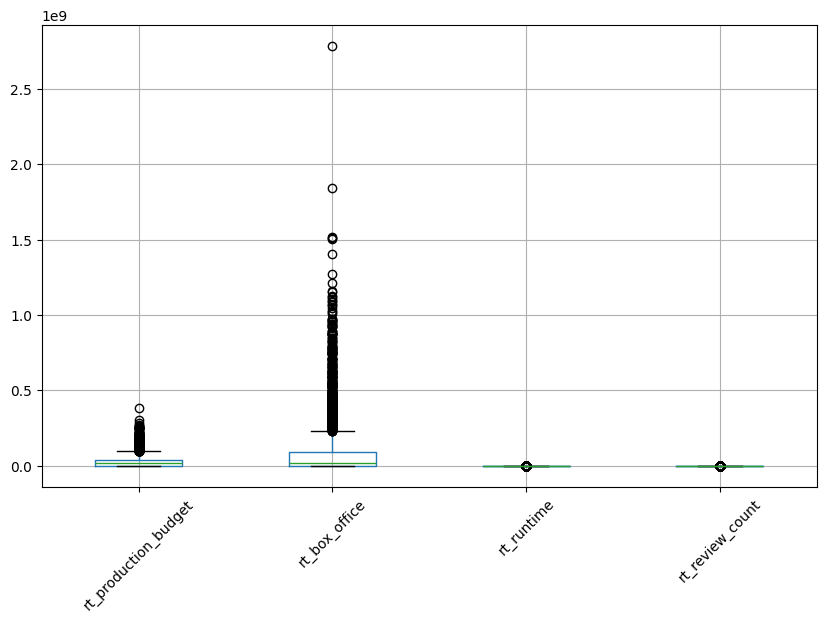

In [17]:
plt.figure(figsize=(10,6))
df_movies[['rt_production_budget', 'rt_box_office', 'rt_runtime', 'rt_review_count']].boxplot()
plt.xticks(rotation=45)
plt.show()

In [18]:
# Define the function to cap outliers based on IQR
def cap_outliers(df_movies, column):
    Q1 = df_movies[column].quantile(0.25)
    Q3 = df_movies[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a mask to identify rows that will be modified
    mask = (df_movies[column] < lower_bound) | (df_movies[column] > upper_bound)
    
    # Apply the capping on both datasets
    df_movies.loc[mask, column] = df_movies[column].clip(lower_bound, upper_bound)

# Apply the function to budget and box office revenue
cap_outliers(df_movies, 'rt_production_budget')
cap_outliers(df_movies, 'rt_box_office')


C:\Users\niush\AppData\Local\Temp\ipykernel_20844\1894852875.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.32297988e+08 2.32297988e+08 2.32297988e+08 2.32297988e+08
 2.3229798

In [19]:
# Define the function to remove outliers based on IQR
def remove_outliers(df_movies, df_credit, column):
    Q1 = df_movies[column].quantile(0.25)
    Q3 = df_movies[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a mask for rows to keep
    mask = (df_movies[column] >= lower_bound) & (df_movies[column] <= upper_bound)

    # Filter both datasets based on this mask
    df_movies_filtered = df_movies[mask]
    df_credit_filtered = df_credit[df_credit['rt_movie_id'].isin(df_movies_filtered['rt_movie_id'])]

    return df_movies_filtered, df_credit_filtered

# Apply the function to runtime and review count
df_movies, df_credit = remove_outliers(df_movies, df_credit, 'rt_runtime')
df_movies, df_credit = remove_outliers(df_movies, df_credit, 'rt_review_count')

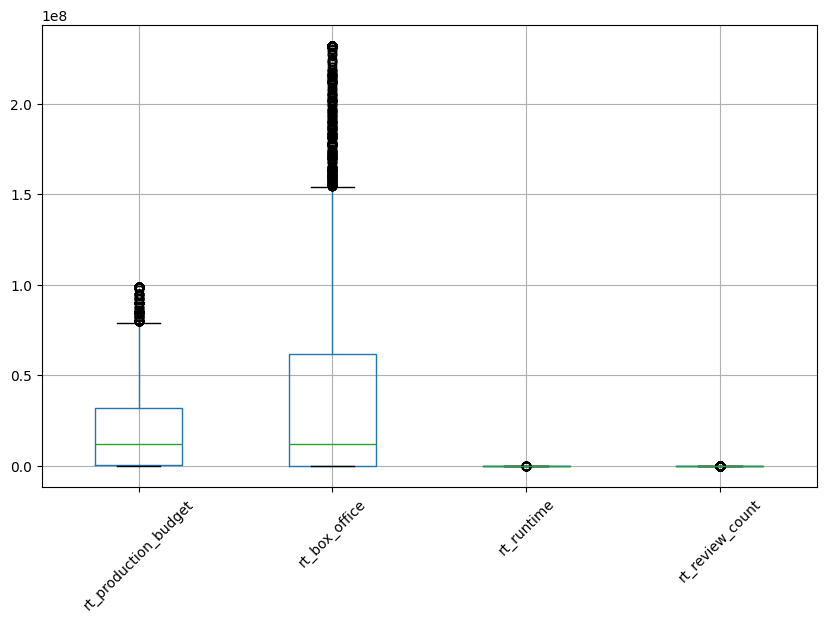

In [20]:
plt.figure(figsize=(10,6))
df_movies[['rt_production_budget', 'rt_box_office', 'rt_runtime', 'rt_review_count']].boxplot()
plt.xticks(rotation=45)
plt.show()

Ensuring Data Consistency: Sorting & Index Reset After Outlier Removal

In [21]:
df_movies.sort_values(by='rt_movie_id', ascending=True, inplace=True)
df_movies.reset_index(drop=True, inplace=True)

df_credit.sort_values(by='rt_movie_id', ascending=True, inplace=True)
df_credit.reset_index(drop=True, inplace=True)

<h4>Encoding & Feature Engineering</h4>

 **<h4>Movies Dataset!!!</h4>** 

**Encoding text data and categories**

2. Encoding for 'rt_original_language' Using Label Encoding

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [23]:
df_merged = df_movies.copy()

In [24]:
#  تبدیل `rt_original_language` به مقدار عددی (Categorical Encoding)
label_encoder = LabelEncoder()
df_merged["rt_original_language"] = label_encoder.fit_transform(df_merged["rt_original_language"])

In [25]:
#  انتخاب ویژگی‌های عددی برای مدل
features = [
    "rt_production_budget", "rt_critics_score", "rt_audience_score",
    "rt_review_count", "rt_original_language"  # زبان اضافه شد
]

#  متغیر هدف (پیش‌بینی فروش فیلم)
target = "rt_box_office"

# ساخت دیتافریم ویژگی‌ها و متغیر هدف
X = df_merged[features]
y = df_merged[target]

#  استانداردسازی ویژگی‌های عددی (به‌جز `rt_original_language`)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[["rt_production_budget", "rt_critics_score", "rt_audience_score", "rt_review_count"]] = scaler.fit_transform(
    X_scaled[["rt_production_budget", "rt_critics_score", "rt_audience_score", "rt_review_count"]])

#  تقسیم داده‌ها به آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#  اطمینان از اینکه `rt_original_language` مقدار `int32` دارد
X_train["rt_original_language"] = X_train["rt_original_language"].astype(np.int32)
X_test["rt_original_language"] = X_test["rt_original_language"].astype(np.int32)


In [26]:
# ** تعریف مدل Deep با `Embedding Layer` برای زبان**
# تعداد زبان‌های منحصربه‌فرد
num_languages = df_merged["rt_original_language"].nunique()
embedding_dim = 6  # تعداد ابعاد بردار

#  ورودی‌های مدل (مشخص کردن `dtype` درست)
input_numeric = layers.Input(shape=(X_train.drop(columns=["rt_original_language"]).shape[1],), dtype="float32")  # ورودی عددی
input_language = layers.Input(shape=(1,), dtype="int32")  # ورودی زبان (int32)

#  Embedding برای `rt_original_language`
embedding = layers.Embedding(input_dim=num_languages, output_dim=embedding_dim)(input_language)
embedding = layers.Flatten()(embedding)

#  ترکیب ورودی عددی و خروجی Embedding
merged = layers.concatenate([input_numeric, embedding])

#  لایه‌های Dense
x = layers.Dense(64, activation="relu")(merged)
x = layers.BatchNormalization()(x)  # افزایش پایداری مدل
x = layers.Dropout(0.3)(x)  # کاهش Overfitting
x = layers.Dense(32, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(16, activation="relu")(x)
output = layers.Dense(1)(x)  # مقدار خروجی (پیش‌بینی `rt_box_office`)

#  ساخت مدل
model = keras.Model(inputs=[input_numeric, input_language], outputs=output)

#  کامپایل مدل
model.compile(optimizer="adam", loss="mse", metrics=["mae"])


In [27]:
# بررسی اینکه `dtype` و `shape` ورودی‌ها درست است
print("\nFinal Check Before Training:")
print("Shape of X_train (excluding language):", X_train.drop(columns=["rt_original_language"]).values.shape)
print("Dtype of X_train (excluding language):", X_train.drop(columns=["rt_original_language"]).values.dtype)

print("Shape of X_train language:", X_train["rt_original_language"].values.reshape(-1, 1).shape)
print("Dtype of X_train language:", X_train["rt_original_language"].values.dtype)



Final Check Before Training:
Shape of X_train (excluding language): (3310, 4)
Dtype of X_train (excluding language): float64
Shape of X_train language: (3310, 1)
Dtype of X_train language: int32


In [28]:
#  آموزش مدل
history = model.fit(
    [
        X_train.drop(columns=["rt_original_language"]).values.astype(np.float32),  # اطمینان از `float32`
        X_train["rt_original_language"].values.astype(np.int32).reshape(-1, 1)  # اطمینان از `int32`
    ],
    y_train, 
    validation_data=(
        [
            X_test.drop(columns=["rt_original_language"]).values.astype(np.float32),  # اطمینان از `float32`
            X_test["rt_original_language"].values.astype(np.int32).reshape(-1, 1)  # اطمینان از `int32`
        ],
        y_test
    ),
    epochs=50, batch_size=32
)


Epoch 1/50


c:\Users\niush\anaconda3\lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6508195082141696.0000 - mae: 46124772.0000 - val_loss: 5954104035639296.0000 - val_mae: 44751164.0000
Epoch 2/50
 58/104 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - loss: 6536172499107840.0000 - mae: 45247956.0000

c:\Users\niush\anaconda3\lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6231377997463552.0000 - mae: 44181788.0000 - val_loss: 5954099203801088.0000 - val_mae: 44751144.0000
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5917024509231104.0000 - mae: 43301292.0000 - val_loss: 5954087392641024.0000 - val_mae: 44751100.0000
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5437343234260992.0000 - mae: 40993080.0000 - val_loss: 5954063770320896.0000 - val_mae: 44751008.0000
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5729203441893376.0000 - mae: 42660092.0000 - val_loss: 5954028873711616.0000 - val_mae: 44750868.0000
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6098433727266816.0000 - mae: 43662044.0000 - val_loss: 5953977870974976.0000 - val_mae: 44750652.0000
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5812757735669760.0000 - mae: 43501320.0000 - val_loss: 5953913446465536.0000 - val_mae: 44750408.0000
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━

In [29]:
# چاپ مشخصات ورودی‌های مدل بعد از آموزش
print("\nModel Inputs Details:")
for layer in model.inputs:
    print(f"Name: {layer.name}, Shape: {layer.shape}, Dtype: {layer.dtype}")

# نمایش خلاصه مدل
model.summary()



Model Inputs Details:
Name: keras_tensor, Shape: (None, 4), Dtype: float32
Name: keras_tensor_1, Shape: (None, 1), Dtype: int32


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 6)      │        210 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 10)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,387 (44.48 KB)

 Trainable params: 3,731 (14.57 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 7,464 (29.16 KB)